In [7]:
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

PROJECT_ROOT = Path.cwd().parent
print(f"Project root: {PROJECT_ROOT}")
DATA_DIR = PROJECT_ROOT / "data"

def read_json(file_path):
    data = None
    with open(file_path, "r") as f:
        data = json.load(f)
    return data

def read_jsonl(file_path: Path) -> list:
    res = []
    with open(file_path, "r") as f:
        for line in f:
            res.append(json.loads(line))
    return res

Project root: /Users/matthewho/Documents/research/ctx_editor


In [3]:
from datasets import load_dataset

/Users/matthewho/miniconda3/envs/collabmem/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
PROJECT_ROOT = Path.cwd().parent


In [3]:
aime24 = load_dataset("Maxwell-Jia/AIME_2024")

Generating train split: 30 examples [00:00, 1195.32 examples/s]


In [4]:
aime24

DatasetDict({
    train: Dataset({
        features: ['ID', 'Problem', 'Solution', 'Answer'],
        num_rows: 30
    })
})

In [6]:
print(aime24["train"][0]["Solution"])

Denote $\log_2(x) = a$, $\log_2(y) = b$, and $\log_2(z) = c$.

Then, we have:
$a-b-c = \frac{1}{2}$,
$-a+b-c = \frac{1}{3}$,
$-a-b+c = \frac{1}{4}$.

Now, we can solve to get $a = \frac{-7}{24}, b = \frac{-9}{24}, c = \frac{-5}{12}$.
Plugging these values in, we obtain $|4a + 3b + 2c|  = \frac{25}{8} \implies \boxed{033}$.


In [7]:
aime24_json = []
for item in aime24["train"]:
    aime24_json.append({
        "question_id": item["ID"],
        "question": item["Problem"],
        "answer": item["Solution"],
    })

In [8]:
print(Path.cwd())

/Users/matthewho/Documents/research/ctx_editor/notebooks


In [11]:
# save aime24_json to PROJECT_ROOT / "data/aime24.json"
PROJECT_ROOT = Path.cwd().parent
target_path = PROJECT_ROOT / "data/aime24.json"
with open(target_path, "w") as f:
    json.dump(aime24_json, f, indent=4)
print(f"Saved aime24_json to {target_path}")

Saved aime24_json to /Users/matthewho/Documents/research/ctx_editor/data/aime24.json


check shard count distribution for AIME24

In [1]:
!ls ../data

aime24.json                         lic_subset30.json
imported_lic_logs/                  lm_eval_aime/
lcb_hard_input.json                 original_lcb_subset.json
lcb_hard_input2.json                plots/
lcb_hard_input3.json                sharded_aime24_5mini.json
lcb_hard_input_full.json            sharded_instructions_600.json
lcb_hard_sharded.json               sota_model_results.csv
lcb_hard_sharded2.json              spider/
lcbh_lc30_sharded.json              t30_dp.json
lcbh_lc30_sharded_m8.json           t30_dp_dev.json
lic_eval_subset.json                test_lcb_hard_sharded.json
lic_mem_learn_set.json              test_shard_aime24_gpt5nano_v1.json
lic_mini_eval4.json                 test_sharded_aime24.json


In [12]:
aime24_path = PROJECT_ROOT / "data/sharded_aime24_5mini.json"

In [13]:
aime24 = read_json(aime24_path)

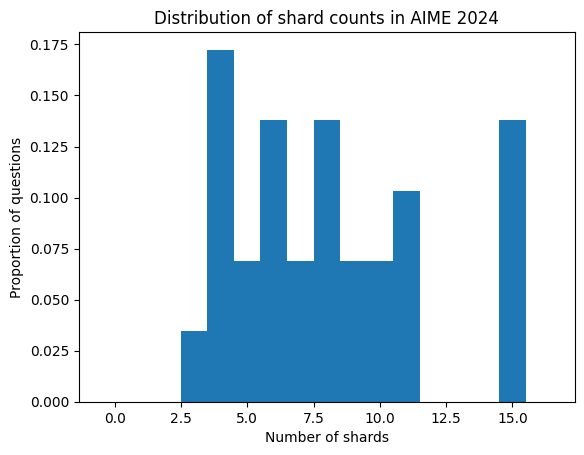

Counter({4: 5, 8: 4, 15: 4, 6: 4, 11: 3, 5: 2, 9: 2, 7: 2, 10: 2, 17: 1, 3: 1})


In [16]:
aime24_shard_counts = [len(e["shards"]) for e in aime24]
# make histogram of shard counts
plt.hist(aime24_shard_counts, bins=np.arange(0, max(aime24_shard_counts) + 1) - 0.5, density=True)
plt.xlabel("Number of shards")
plt.ylabel("Proportion of questions")
plt.title("Distribution of shard counts in AIME 2024")
plt.show()
print(Counter(aime24_shard_counts))